# 该脚本用于在数据中添加差分到时

注意：差分到时有2种生成方式：

### 1. 基于绝对到时生成，例如，地震 si 到 台站 rj 和 rk 的到时差，可以有两个绝对到时相减得到，即

到时差_i,jk = 到时_i,j - 到时_i,k

这种生成方式不依赖波形数据，但是相对的，误差会大一些。本脚本使用该方法生成差分到时。

### 2. 另一种生成方式可以基于波形互相关

可以参考论文

VanDecar, J. C., & Crosson, R. S. (1990). Determination of teleseismic relative phase arrival times using multi-channel cross-correlation and least squares. Bulletin of the Seismological Society of America, 80(1), 150-169.

这种生成方式的误差较小，但整体代价较大，且需要波形数据，以及选择合适的时间窗和筛选阈值。只有当波形足够相似（互相关系数较大）时，提取出来的互相关到时差才具有可靠性。

In [1]:
# 载入 TomoATT 数据处理函数
import pytomoatt as pta
from pytomoatt.utils.common import km2deg

# 1. 读取到时数据文件

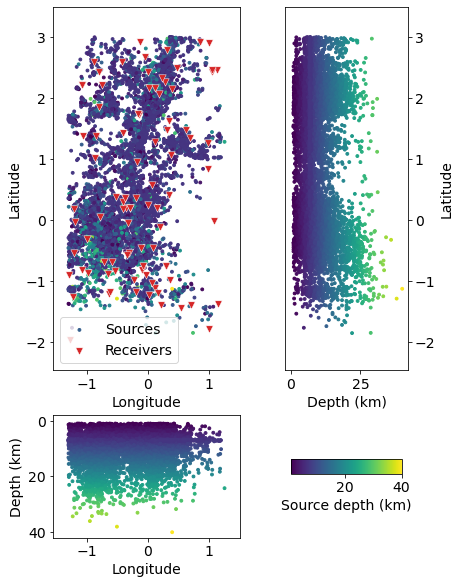

In [2]:
# 读取数据
fname = "output_data/step3_src_rec_filtered.dat"
sr = pta.SrcRec.read(fname)

# 数据画图（可选） fname = None 可以不保存图片
sr.plot();

# 2. 生成共源差分到时，该数据表示同一地震，被临近台站接收到的差分到时

共源差分到时对震源位置不确定性不敏感，不受发震时刻误差影响，有助于提高成像可靠性 （因此，有成像需求，可以加入该类数据）

这里设置了2个阈值，台站间距小于 100 km, 两条大圆路径夹角小于 30 度

这些阈值是为了保证 两条路径尽可能在震源附近有 overlap，这样才能体现共源差分数据的优势：消除震源不确定性对成像结果的影响。

不加约束也可以，那些不满足约束的数据，其两条路径在震源附近没有很强的 overlap，效果相当于单独的两条绝对到时数据约束。

In [3]:
# 台站间距小于 100 km, 两条大圆路径夹角小于 30 度
dis_thd = 100 # distance between two stations should be less than 100 km
azi_thd = 30  # the angle bwteen two great circle paths from the common source to two separated receivers should be less than 30

sr.generate_double_difference(type="cs", max_azi_gap=azi_thd, max_dist_gap=km2deg(dis_thd), dis_type='dis_pair', same_phase=False)


Generating cs: 100%|██████████| 20644/20644 [00:30<00:00, 682.46it/s] 
2026-08-04 19:25:00,489 [SrcRec] INFO: rec_points_cs after generation: (82795, 14)


# 3. (可选) 生成共台差分到时，该数据表示近邻地震，对同一台站接收到的差分到时

共台差分到时对台站处的结构不确定性不敏感，有助于改善地震之间的相对定位精度 （因此，有定位需求，可以加入该类数据）

这里设置了2个阈值，地震间距小于 3 km, 两条大圆路径夹角小于 5 度

这些阈值是为了保证 两条路径尽可能在有 overlap，使得差分到时重点约束震源相对位置与震源之间的结构

上述阈值设置较共源差分到时的阈值更严苛，是因为地震数量往往很多，较大的阈值可能导致非常庞大的数据规模

但是，当震源不确定性较大时，共台差分到时会放大震源不确定性对成像结果的影响，可能导致潜在的成像误差

In [4]:
# 由于 ISC 上的 Turkey 区域的数据，其震源不确定性较高，因此在该成像任务中，不使用共台差分到时。
# 如果有高精度定位的需求，可以考虑加入共台差分到时数据

# 地震间距小于 3 km, 两条大圆路径夹角小于 5 度
# dis_thd = 3  # distance between two earthquakes should be less than 3 km
# azi_thd = 5  # the angle bwteen two great circle paths from the common receiver to two separated sources should be less than 5 degree

# sr.generate_double_difference(type="cr", max_azi_gap=azi_thd, max_dist_gap=km2deg(dis_thd), same_phase=False)

# 4. 数据输出

In [5]:
# 将数据输出到指定目录
import os

# 指定数据目录
out_path = "output_data"
os.makedirs(out_path,exist_ok=True)

# 储存为TomoATT格式数据文件
out_fname = f"{out_path}/step4_src_rec_cs.dat"
sr.write(out_fname)

Writing src_rec file: 100%|██████████| 20644/20644 [00:00<00:00, 85557.70it/s]


# 5. 将该数据用于实际层析成像任务

In [6]:
# 指定数据目录
out_path = "../1_src_rec_files"
os.makedirs(out_path,exist_ok=True)

# 储存为TomoATT格式数据文件
out_fname = f"{out_path}/src_rec_file.dat"
sr.write(out_fname)

Writing src_rec file: 100%|██████████| 20644/20644 [00:00<00:00, 79189.20it/s]
